<a href="https://colab.research.google.com/github/Sriya777/Speech-Processing/blob/main/speechprocessing_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sriya Nistala

BL.EN.U4AIE23034

Lab 5

Task-1:
(i) Construct a single triangular filter with points = [(10, 20, 30)] (i.e. a=10, b=20, c=30) and plot the triangular filter.

Triangle Points: a = 10 b = 20 c = 30


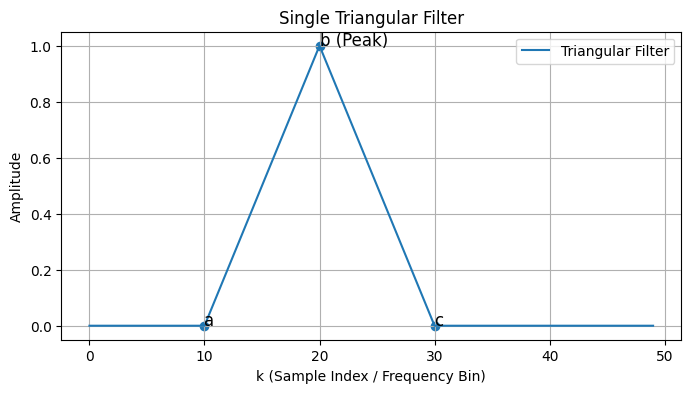

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)
    for i in range(len(k)):
        if k[i] < a:
            H[i] = 0
        elif a <= k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif b <= k[i] <= c:
            H[i] = (c - k[i]) / (c - b)
        else:
            H[i] = 0
    return H

# Parameters
a, b, c = 10, 20, 30
k = np.arange(0, 50)
H = triangular_filter(k, a, b, c)

print("Triangle Points: a =", a, "b =", b, "c =", c)

plt.figure(figsize=(8,4))
plt.plot(k, H, label="Triangular Filter")

# Highlight important points
plt.scatter([a, b, c], [0, 1, 0])
plt.text(a, 0, 'a', fontsize=12)
plt.text(b, 1, 'b (Peak)', fontsize=12)
plt.text(c, 0, 'c', fontsize=12)

plt.xlabel("k (Sample Index / Frequency Bin)")
plt.ylabel("Amplitude")
plt.title("Single Triangular Filter")
plt.legend()
plt.grid()
plt.show()

(ii) Construct multiple triangles with points = [(10, 20, 30), (20, 30, 40), (30, 40, 50)] and plot multiple triangular filter.

Triangle: a=10, b=20, c=30
Triangle: a=20, b=30, c=40
Triangle: a=30, b=40, c=50


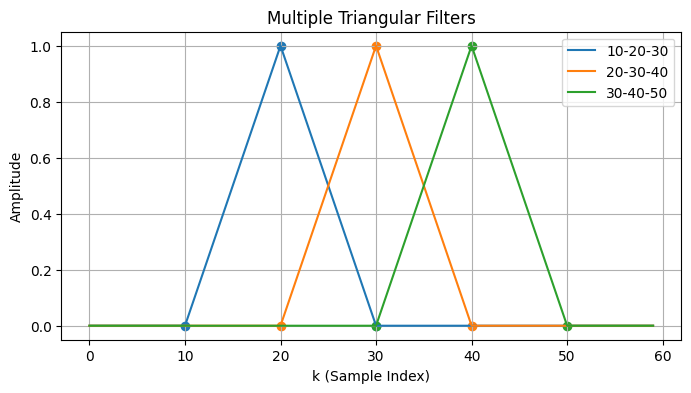

In [ ]:
triangles = [(10,20,30), (20,30,40), (30,40,50)]
k = np.arange(0, 60)

plt.figure(figsize=(8,4))

for (a,b,c) in triangles:
    H = triangular_filter(k, a, b, c)
    print(f"Triangle: a={a}, b={b}, c={c}")

    plt.plot(k, H, label=f"{a}-{b}-{c}")
    plt.scatter([a, b, c], [0, 1, 0])  # highlight peaks

plt.xlabel("k (Sample Index)")
plt.ylabel("Amplitude")
plt.title("Multiple Triangular Filters")
plt.legend()
plt.grid()
plt.show()

(iii) Change 𝑎,𝑏,𝑐and observe shape changes. make a wider triangle and make a narrow triangle

Wide Triangle: (10, 30, 50)
Narrow Triangle: (20, 25, 30)


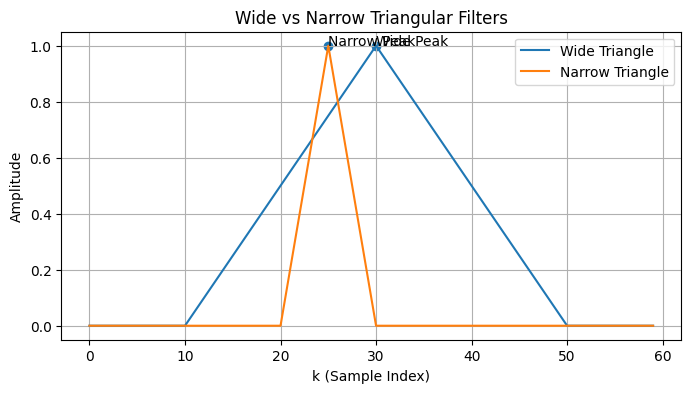

In [ ]:
k = np.arange(0, 60)

# Wide
a1, b1, c1 = 10, 30, 50
H_wide = triangular_filter(k, a1, b1, c1)

# Narrow
a2, b2, c2 = 20, 25, 30
H_narrow = triangular_filter(k, a2, b2, c2)

print("Wide Triangle:", (a1, b1, c1))
print("Narrow Triangle:", (a2, b2, c2))

plt.figure(figsize=(8,4))

plt.plot(k, H_wide, label="Wide Triangle")
plt.plot(k, H_narrow, label="Narrow Triangle")

# Highlight peaks
plt.scatter([b1, b2], [1, 1])
plt.text(b1, 1, 'Wide Peak')
plt.text(b2, 1, 'Narrow Peak')

plt.xlabel("k (Sample Index)")
plt.ylabel("Amplitude")
plt.title("Wide vs Narrow Triangular Filters")
plt.legend()
plt.grid()
plt.show()

Report the following:

(i) Plot FFT Bin vs Frequency plot (X-axis → FFT bin index, Y-axis → actual frequency)

First 10 FFT bins: [0 1 2 3 4 5 6 7 8 9]
First 10 Frequencies: [  0.    31.25  62.5   93.75 125.   156.25 187.5  218.75 250.   281.25]


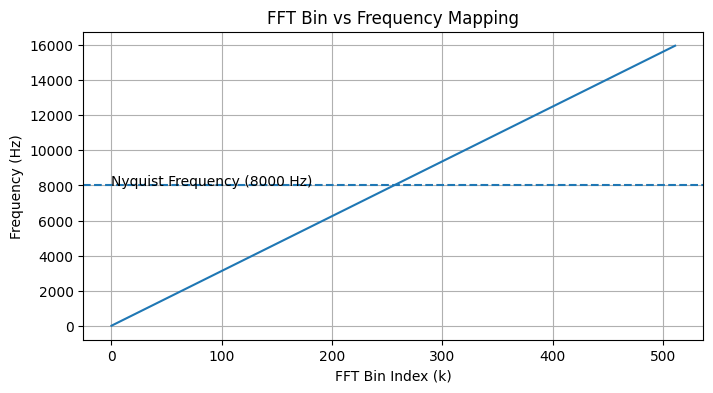

In [ ]:
fs = 16000
N = 512

k = np.arange(0, N)
frequencies = (k * fs) / N

print("First 10 FFT bins:", k[:10])
print("First 10 Frequencies:", frequencies[:10])

plt.figure(figsize=(8,4))
plt.plot(k, frequencies)

# Highlight Nyquist frequency
plt.axhline(y=fs/2, linestyle='--')
plt.text(0, fs/2, 'Nyquist Frequency (8000 Hz)')

plt.xlabel("FFT Bin Index (k)")
plt.ylabel("Frequency (Hz)")
plt.title("FFT Bin vs Frequency Mapping")
plt.grid()
plt.show()

(ii) Plot Mel Points

Mel Points:
 [   0.          135.2391927   270.4783854   405.7175781   540.9567708
  676.1959635   811.4351562   946.6743489  1081.9135416  1217.1527343
 1352.391927   1487.6311197  1622.8703124  1758.10950511 1893.34869781
 2028.58789051 2163.82708321 2299.06627591 2434.30546861 2569.54466131
 2704.78385401 2840.02304671]


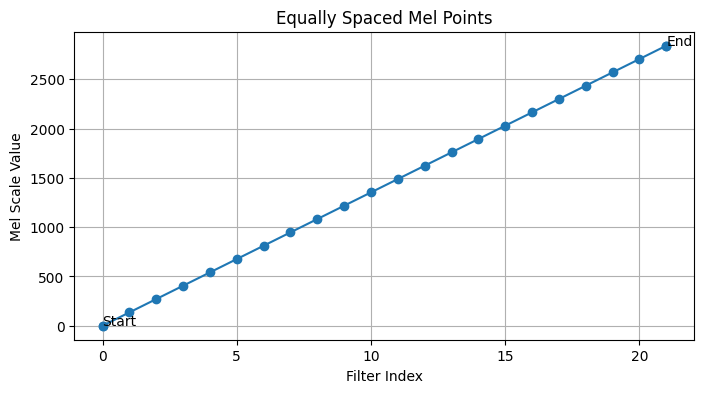

In [ ]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f/700)

def mel_to_hz(m):
    return 700 * (10**(m/2595) - 1)

M = 20
fmin = 0
fmax = fs // 2

mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

mel_points = np.linspace(mel_min, mel_max, M+2)

print("Mel Points:\n", mel_points)

plt.figure(figsize=(8,4))
plt.plot(mel_points, 'o-')

# Highlight start and end
plt.scatter([0, len(mel_points)-1], [mel_min, mel_max])
plt.text(0, mel_min, 'Start')
plt.text(len(mel_points)-1, mel_max, 'End')

plt.xlabel("Filter Index")
plt.ylabel("Mel Scale Value")
plt.title("Equally Spaced Mel Points")
plt.grid()
plt.show()

(iii) Print the triangular filter points (values of a, b, c for all filters)

In [ ]:
hz_points = mel_to_hz(mel_points)
bins = np.floor((N+1) * hz_points / fs).astype(int)

print("\nTriangular Filter Points (a, b, c):")

for m in range(1, M+1):
    a = bins[m-1]
    b = bins[m]
    c = bins[m+1]
    print(f"Filter {m}: a={a}, b={b}, c={c}")


Triangular Filter Points (a, b, c):
Filter 1: a=0, b=2, c=6
Filter 2: a=2, b=6, c=9
Filter 3: a=6, b=9, c=13
Filter 4: a=9, b=13, c=18
Filter 5: a=13, b=18, c=23
Filter 6: a=18, b=23, c=29
Filter 7: a=23, b=29, c=36
Filter 8: a=29, b=36, c=43
Filter 9: a=36, b=43, c=52
Filter 10: a=43, b=52, c=61
Filter 11: a=52, b=61, c=72
Filter 12: a=61, b=72, c=84
Filter 13: a=72, b=84, c=97
Filter 14: a=84, b=97, c=113
Filter 15: a=97, b=113, c=130
Filter 16: a=113, b=130, c=150
Filter 17: a=130, b=150, c=172
Filter 18: a=150, b=172, c=196
Filter 19: a=172, b=196, c=224
Filter 20: a=196, b=224, c=256


(iv) Plot Mel filter bank

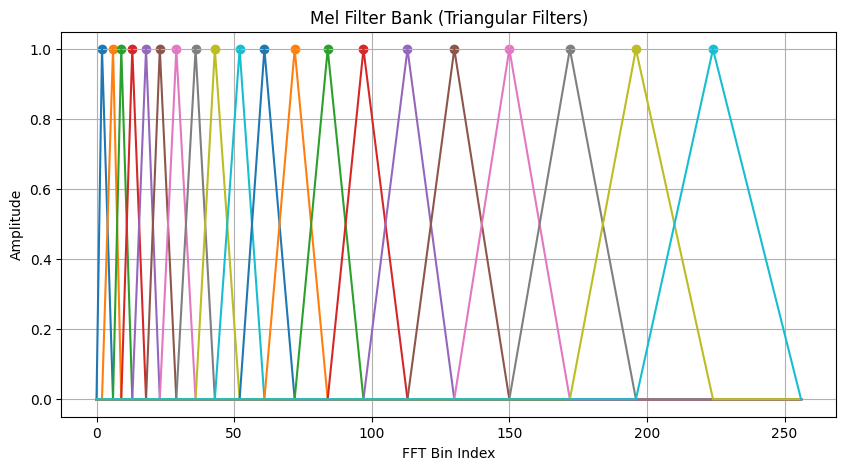

In [ ]:
filter_bank = np.zeros((M, N//2 + 1))

plt.figure(figsize=(10,5))

for m in range(1, M+1):
    f_m_minus = bins[m-1]
    f_m = bins[m]
    f_m_plus = bins[m+1]

    for k in range(f_m_minus, f_m):
        filter_bank[m-1, k] = (k - f_m_minus) / (f_m - f_m_minus)

    for k in range(f_m, f_m_plus):
        filter_bank[m-1, k] = (f_m_plus - k) / (f_m_plus - f_m)

    plt.plot(filter_bank[m-1])

    # Highlight peak
    plt.scatter(f_m, 1)

plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.title("Mel Filter Bank (Triangular Filters)")
plt.grid()
plt.show()

(v) Change the parameters and visualize the results

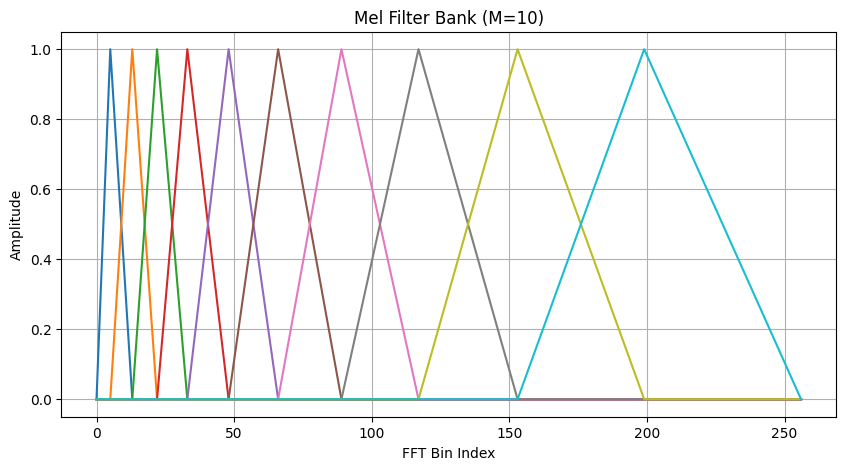

In [ ]:
M_new = 10
mel_points_new = np.linspace(mel_min, mel_max, M_new+2)
hz_points_new = mel_to_hz(mel_points_new)
bins_new = np.floor((N+1) * hz_points_new / fs).astype(int)

filter_bank_new = np.zeros((M_new, N//2 + 1))

plt.figure(figsize=(10,5))

for m in range(1, M_new+1):
    for k in range(bins_new[m-1], bins_new[m]):
        filter_bank_new[m-1, k] = (k - bins_new[m-1]) / (bins_new[m] - bins_new[m-1])

    for k in range(bins_new[m], bins_new[m+1]):
        filter_bank_new[m-1, k] = (bins_new[m+1] - k) / (bins_new[m+1] - bins_new[m])

    plt.plot(filter_bank_new[m-1])

plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.title("Mel Filter Bank (M=10)")
plt.grid()
plt.show()


Sampling Frequency = 8000 Hz
FFT Bins:
 [  0   4   8  14  19  25  32  39  47  56  66  76  88 101 114 130 146 164
 184 206 230 256]

Sampling Frequency = 16000 Hz
FFT Bins:
 [  0   2   6   9  13  18  23  29  36  43  52  61  72  84  97 113 130 150
 172 196 224 256]

Sampling Frequency = 22050 Hz
FFT Bins:
 [  0   2   5   8  11  15  20  25  31  38  46  54  65  76  90 105 123 143
 166 192 222 256]


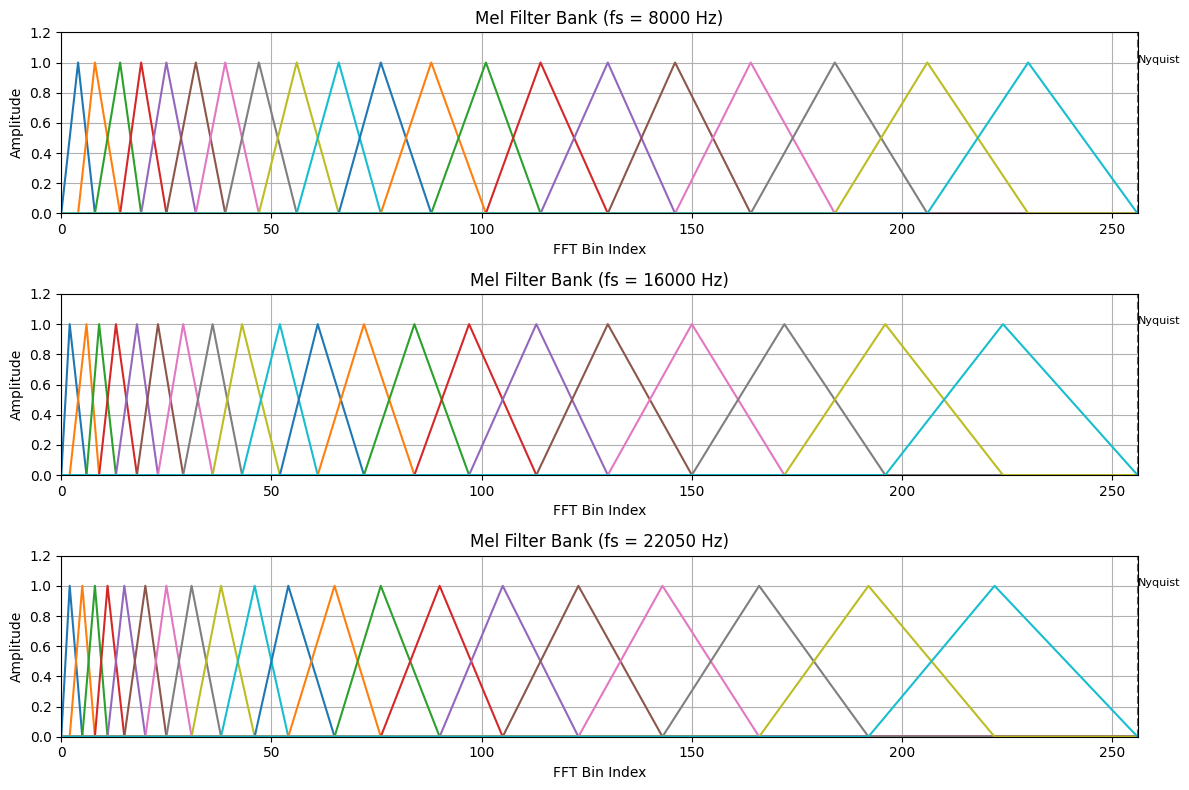

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Conversion Functions
# ----------------------------
def hz_to_mel(f):
    return 2595 * np.log10(1 + f/700)

def mel_to_hz(m):
    return 700 * (10**(m/2595) - 1)

# ----------------------------
# Parameters
# ----------------------------
N = 512
M = 20

sampling_freqs = [8000, 16000, 22050]

# ----------------------------
# Plot Setup
# ----------------------------
plt.figure(figsize=(12,8))

for idx, fs in enumerate(sampling_freqs):

    fmin = 0
    fmax = fs // 2   # Nyquist

    # Step 1: Mel limits
    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    # Step 2: Mel points
    mel_points = np.linspace(mel_min, mel_max, M+2)

    # Step 3: Convert to Hz
    hz_points = mel_to_hz(mel_points)

    # Step 4: Convert to FFT bins
    bins = np.floor((N+1) * hz_points / fs).astype(int)

    print(f"\nSampling Frequency = {fs} Hz")
    print("FFT Bins:\n", bins)

    # Step 5: Create filter bank
    filter_bank = np.zeros((M, N//2 + 1))

    for m in range(1, M+1):
        f_m_minus = bins[m-1]
        f_m = bins[m]
        f_m_plus = bins[m+1]

        for k in range(f_m_minus, f_m):
            filter_bank[m-1, k] = (k - f_m_minus) / (f_m - f_m_minus)

        for k in range(f_m, f_m_plus):
            filter_bank[m-1, k] = (f_m_plus - k) / (f_m_plus - f_m)

    # ----------------------------
    # Plot each in subplot
    # ----------------------------
    plt.subplot(3,1,idx+1)

    for i in range(M):
        plt.plot(filter_bank[i])

    plt.title(f"Mel Filter Bank (fs = {fs} Hz)")
    plt.xlabel("FFT Bin Index")
    plt.ylabel("Amplitude")

    # Highlight Nyquist bin
    plt.axvline(x=N//2, linestyle='--')
    plt.text(N//2, 1, "Nyquist", fontsize=8)

    plt.xlim(0, N//2)
    plt.ylim(0, 1.2)
    plt.grid()

plt.tight_layout()
plt.show()

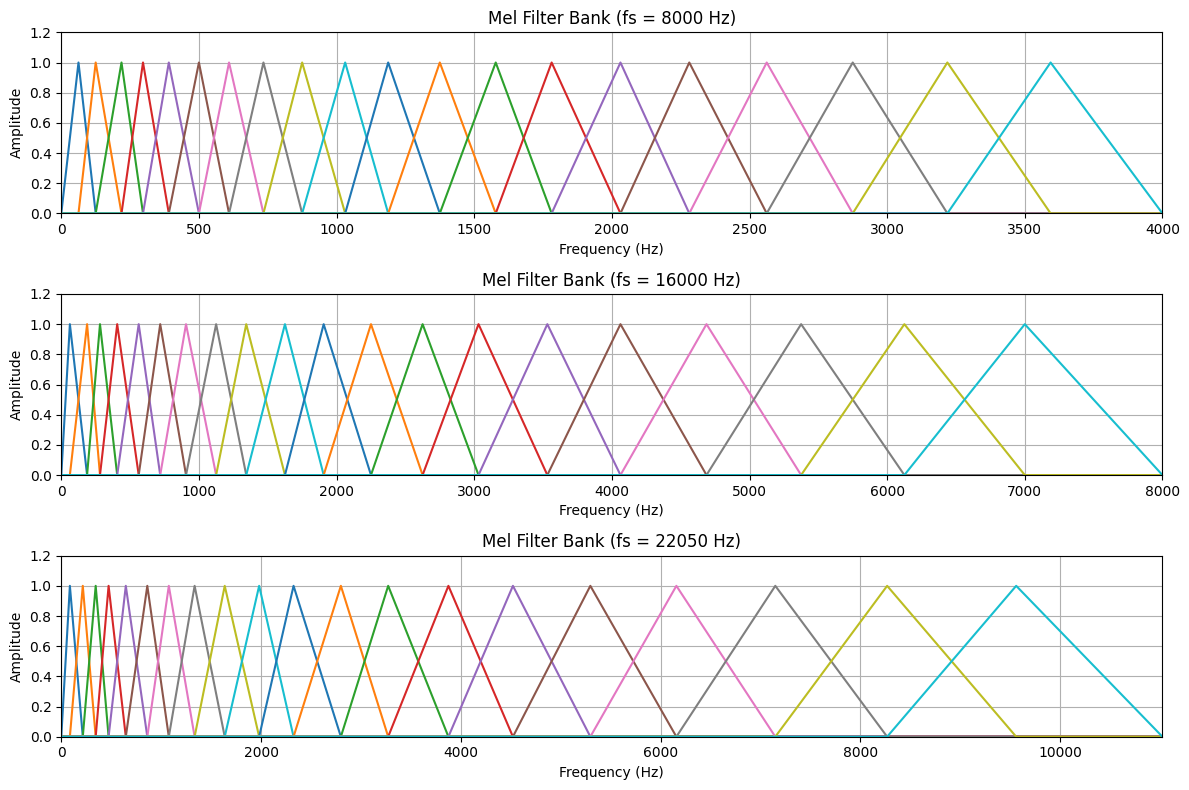

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hz_to_mel(f):
    return 2595 * np.log10(1 + f/700)

def mel_to_hz(m):
    return 700 * (10**(m/2595) - 1)

N = 512
M = 20
sampling_freqs = [8000, 16000, 22050]

plt.figure(figsize=(12,8))

for idx, fs in enumerate(sampling_freqs):

    fmin = 0
    fmax = fs // 2

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    mel_points = np.linspace(mel_min, mel_max, M+2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((N+1) * hz_points / fs).astype(int)

    filter_bank = np.zeros((M, N//2 + 1))

    for m in range(1, M+1):
        for k in range(bins[m-1], bins[m]):
            filter_bank[m-1, k] = (k - bins[m-1]) / (bins[m] - bins[m-1])
        for k in range(bins[m], bins[m+1]):
            filter_bank[m-1, k] = (bins[m+1] - k) / (bins[m+1] - bins[m])

    #  Convert bins → frequency for x-axis
    freq_axis = (np.arange(0, N//2 + 1) * fs) / N

    plt.subplot(3,1,idx+1)

    for i in range(M):
        plt.plot(freq_axis, filter_bank[i])

    plt.title(f"Mel Filter Bank (fs = {fs} Hz)")
    plt.xlabel("Frequency (Hz)")   # ✅ FIXED
    plt.ylabel("Amplitude")

    plt.xlim(0, fmax)
    plt.ylim(0, 1.2)

    plt.grid()

plt.tight_layout()
plt.show()